In [2]:
# ==========================================
# Jupyter 환경에서 한글 폰트 직접 등록 (NanumGothic, URL 안정 버전)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, urllib.request

# 1️⃣ 폰트 저장 경로 설정
font_dir = "/home/user/.fonts"
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NanumGothic.ttf")

# 2️⃣ 안정적인 다운로드 URL (Google Fonts CDN)
font_url = (
    "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
)

if not os.path.exists(font_path):
    print("📦 나눔고딕 폰트 다운로드 중...")
    urllib.request.urlretrieve(font_url, font_path)
    print("✅ 나눔고딕 폰트 다운로드 및 저장 완료")
else:
    print("✅ 이미 나눔고딕 폰트가 존재합니다.")

# 3️⃣ 폰트 등록 및 적용
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"🎨 현재 적용된 폰트: {plt.rcParams['font.family']}")

# 폰트가 등록되어 있다면 추가
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
    print("✅ 나눔고딕 폰트 적용 완료:", plt.rcParams["font.family"])
else:
    print("⚠️ 나눔고딕 폰트를 찾을 수 없습니다. 경로를 확인하세요.")

✅ 이미 나눔고딕 폰트가 존재합니다.
🎨 현재 적용된 폰트: ['NanumGothic']
✅ 나눔고딕 폰트 적용 완료: ['NanumGothic']


총 데이터 건수: 483 (보수 231, 민원 252)


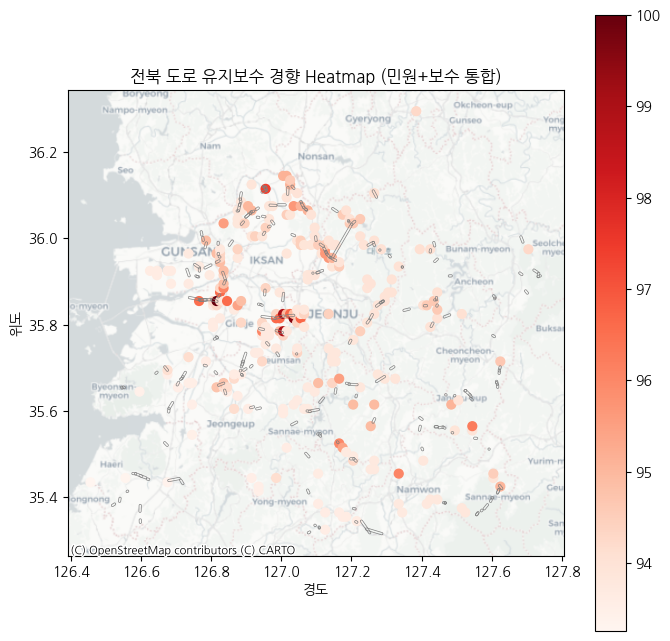

📍 우선 관리 대상 상위 10개 지역:


type,lon_bin,lat_bin,보수,민원,risk_score
31,126.81,35.85,2,10,100.000000
126,127.03,35.81,4,7,99.530516
111,127.00,35.82,7,3,98.946525
110,127.00,35.78,8,2,98.923623
94,126.95,36.11,3,4,97.366312
138,127.05,35.81,0,6,96.679263
120,127.02,35.82,3,3,96.667812
105,126.99,35.81,3,3,96.644910
102,126.98,35.81,6,0,96.639185
35,126.82,35.87,6,0,96.581931


In [3]:
# ==========================================
# 전북 도로 유지보수 경향 탐지 & 우선순위화
# ==========================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx

# ---------- 데이터 경로 ----------
space_dir = "/home/user/ai/AnKiHyeon/공공데이터_원본/전북특별자치도_도로유지보수이력_공간정보_20211221"
info_dir = "/home/user/ai/AnKiHyeon/공공데이터_원본/전북특별자치도_도로유지보수이력_현황_20211221"

# ---------- 공간데이터 로드 ----------
overlay = gpd.read_file(f"{space_dir}/전라북도_지방도_덧씌우기_사업_대상지.shp").to_crs(
    4326
)
repair = gpd.read_file(f"{space_dir}/전라북도__지방도_포트홀_보수_데이터.shp").to_crs(
    4326
)
compl = gpd.read_file(
    f"{space_dir}/전라북도_지방도_포트홀_민원_발생_데이터..shp"
).to_crs(4326)

# ---------- 통합 포인트데이터 ----------
repair["type"] = "보수"
compl["type"] = "민원"
merged = pd.concat([repair, compl], ignore_index=True)
merged = gpd.GeoDataFrame(merged, geometry="geometry", crs=4326)

print(f"총 데이터 건수: {len(merged)} (보수 {len(repair)}, 민원 {len(compl)})")

# ---------- 밀도 기반 위험도 계산 ----------
# 격자 단위(0.01도 ≈ 약 1km)로 집계
merged["lon_bin"] = (merged.geometry.x // 0.01) * 0.01
merged["lat_bin"] = (merged.geometry.y // 0.01) * 0.01

risk_grid = (
    merged.groupby(["lon_bin", "lat_bin", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

risk_grid["total"] = risk_grid.sum(axis=1)
risk_grid["risk_score"] = (risk_grid["total"] / risk_grid["total"].max()) * 100

# ---------- GeoDataFrame 변환 ----------
risk_grid["geometry"] = [
    Point(x + 0.005, y + 0.005)
    for x, y in zip(risk_grid["lon_bin"], risk_grid["lat_bin"])
]
risk_gdf = gpd.GeoDataFrame(risk_grid, geometry="geometry", crs=4326)

# ---------- 시각화 ----------
fig, ax = plt.subplots(figsize=(8, 8))
risk_gdf.plot(ax=ax, column="risk_score", cmap="Reds", markersize=40, legend=True)
overlay.boundary.plot(ax=ax, color="gray", linewidth=0.5)
ctx.add_basemap(ax, crs=risk_gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron)
plt.title("전북 도로 유지보수 경향 Heatmap (민원+보수 통합)")
plt.xlabel("경도")
plt.ylabel("위도")
plt.show()

# ---------- 우선순위 상위 지역 추출 ----------
top_risk = risk_gdf.sort_values("risk_score", ascending=False).head(10)
print("📍 우선 관리 대상 상위 10개 지역:")
display(top_risk[["lon_bin", "lat_bin", "보수", "민원", "risk_score"]])

In [9]:
import pandas as pd
import geopandas as gpd

SPACE_DIR = "/home/user/ai/AnKiHyeon/공공데이터_원본/전북특별자치도_도로유지보수이력_공간정보_20211221"

repair = gpd.read_file(f"{SPACE_DIR}/전라북도__지방도_포트홀_보수_데이터.shp")
compl = gpd.read_file(f"{SPACE_DIR}/전라북도_지방도_포트홀_민원_발생_데이터..shp")


# ---- 날짜 전처리 ----
def parse_mmdd(text):
    import re

    if pd.isna(text):
        return None
    s = str(text)
    s = re.sub(r"[^\d]", "-", s)
    s = re.sub(r"-+", "-", s).strip("-")
    m = re.match(r"^(\d{1,2})-(\d{1,2})$", s)
    if not m:
        return None
    mm, dd = int(m.group(1)), int(m.group(2))
    return f"{mm:02d}-{dd:02d}"


def parse_repair_date(row):
    y = str(row.get("연도", "")).strip()
    md = parse_mmdd(row.get("일 자", ""))
    if not (y and md):
        return pd.NaT
    try:
        return pd.to_datetime(f"{y}-{md}", errors="coerce")
    except:
        return pd.NaT


repair["date"] = repair.apply(parse_repair_date, axis=1)

# 민원 컬럼 깨짐 대응
rename_map = {
    "¹Î¿øÀÏÀÚ": "민원일자",
    "¹Î¿øÀ§Ä¡": "민원위치",
    "¹Î¿ø³»¿ë": "민원내용",
    "À§µµ": "위도",
    "°æµµ": "경도",
}
compl = compl.rename(
    columns={k: v for k, v in rename_map.items() if k in compl.columns}
)
compl["date"] = pd.to_datetime(compl["민원일자"], errors="coerce")

# ---- 기간 요약 ----
print("📆 보수 데이터 기간:", repair["date"].min(), "~", repair["date"].max())
print("📆 민원 데이터 기간:", compl["date"].min(), "~", compl["date"].max())

print(
    f"보수 유효건수: {repair['date'].notna().sum()} | 민원 유효건수: {compl['date'].notna().sum()}"
)

📆 보수 데이터 기간: 2021-01-21 00:00:00 ~ 2021-07-05 00:00:00
📆 민원 데이터 기간: 2018-01-06 00:00:00 ~ 2021-07-04 00:00:00
보수 유효건수: 231 | 민원 유효건수: 252


In [10]:
from datetime import timedelta
import pandas as pd

# === 파라미터 설정 ===
LOOKBACK_DAYS = 60
HORIZON_DAYS = 30
FREQ = "15D"

min_date = max(repair["date"].min(), compl["date"].min())
max_date = min(repair["date"].max(), compl["date"].max())

cutoffs = pd.date_range(
    min_date + timedelta(days=LOOKBACK_DAYS),
    max_date - timedelta(days=HORIZON_DAYS),
    freq=FREQ,
)

print("✅ 생성된 cutoff 개수:", len(cutoffs))
for d in cutoffs:
    print("-", d.strftime("%Y-%m-%d"))

print("\n⏱️ 분석 기간 요약:")
print(f"  • 데이터 범위: {min_date.date()} ~ {max_date.date()}")
print(f"  • LOOKBACK: {LOOKBACK_DAYS}일, HORIZON: {HORIZON_DAYS}일")
print(f"  • 샘플 수: {len(cutoffs)}개 (스냅샷 단위: {FREQ})")

✅ 생성된 cutoff 개수: 5
- 2021-03-22
- 2021-04-06
- 2021-04-21
- 2021-05-06
- 2021-05-21

⏱️ 분석 기간 요약:
  • 데이터 범위: 2021-01-21 ~ 2021-07-04
  • LOOKBACK: 60일, HORIZON: 30일
  • 샘플 수: 5개 (스냅샷 단위: 15D)


전체 좌표 범위: (150599, 202712) ~ (263381, 310437)
생성된 격자 수: 48816

📆 현재 윈도우: 2021-01-21 ~ 2021-03-22
보수: 91건 | 민원: 20건


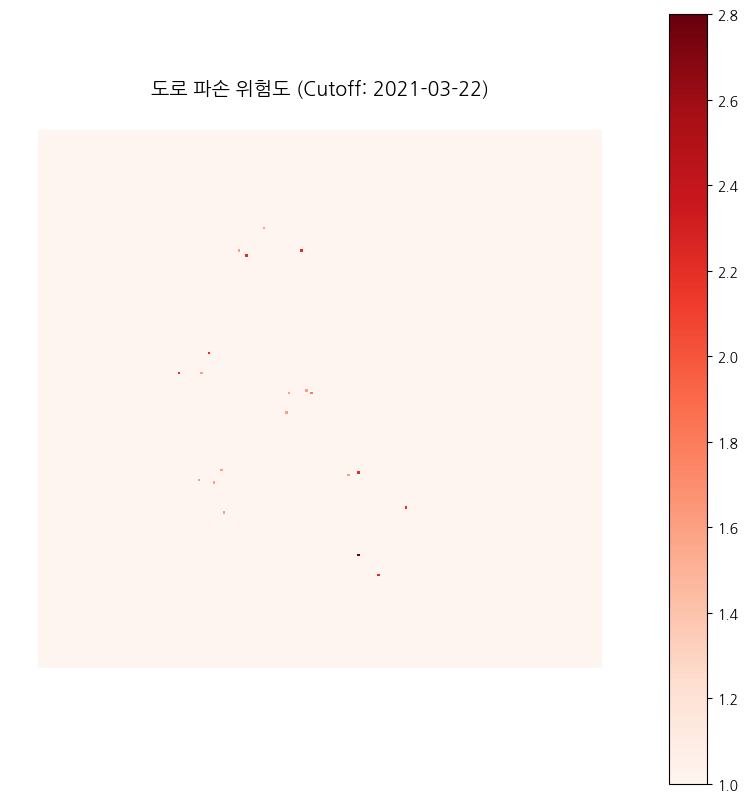

,repair_cnt,compl_cnt,risk_score
27693,4,1,2.8
29413,3,1,2.2
14814,3,1,2.2
31816,3,1,2.2
18093,3,1,2.2
12214,3,1,2.2
22847,3,1,2.2
27726,3,1,2.2
23654,1,3,1.8
15847,2,1,1.6


In [11]:
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

# ===== (1) 좌표계 맞추기 =====
repair = repair.to_crs(5181)
compl = compl.to_crs(5181)

# 전체 범위 계산
xmin, ymin, xmax, ymax = compl.total_bounds
print(f"전체 좌표 범위: ({xmin:.0f}, {ymin:.0f}) ~ ({xmax:.0f}, {ymax:.0f})")

# ===== (2) 500m 격자 생성 =====
grid_size = 500  # 500m
cols = list(np.arange(xmin, xmax, grid_size))
rows = list(np.arange(ymin, ymax, grid_size))

polygons = []
for x in cols:
    for y in rows:
        polygons.append(box(x, y, x + grid_size, y + grid_size))
grid = gpd.GeoDataFrame({"geometry": polygons}, crs=5181)
print(f"생성된 격자 수: {len(grid)}")

# ===== (3) 특정 시점(cutoff)에서의 lookback 윈도우 설정 =====
cutoff = cutoffs[0]  # 첫 번째 시점 예시 (2021-03-22)
start_date = cutoff - timedelta(days=LOOKBACK_DAYS)

print(f"\n📆 현재 윈도우: {start_date.date()} ~ {cutoff.date()}")

repair_win = repair[(repair["date"] >= start_date) & (repair["date"] <= cutoff)]
compl_win = compl[(compl["date"] >= start_date) & (compl["date"] <= cutoff)]

print(f"보수: {len(repair_win)}건 | 민원: {len(compl_win)}건")

# ===== (4) 각 격자별 교차 건수 집계 =====
repair_join = gpd.sjoin(grid, repair_win, predicate="contains", how="left")
compl_join = gpd.sjoin(grid, compl_win, predicate="contains", how="left")

grid["repair_cnt"] = repair_join.groupby(repair_join.index).size()
grid["compl_cnt"] = compl_join.groupby(compl_join.index).size()
grid[["repair_cnt", "compl_cnt"]] = grid[["repair_cnt", "compl_cnt"]].fillna(0)

# ===== (5) 위험 점수 계산 (가중 평균 예시) =====
grid["risk_score"] = (grid["repair_cnt"] * 0.6) + (grid["compl_cnt"] * 0.4)

# ===== (6) 시각화 =====
fig, ax = plt.subplots(figsize=(10, 10))
grid.plot(ax=ax, column="risk_score", cmap="Reds", legend=True)
plt.title(f"도로 파손 위험도 (Cutoff: {cutoff.date()})", fontsize=14)
plt.axis("off")
plt.show()

# ===== (7) 상위 10개 위험 격자 출력 =====
top10 = grid.sort_values("risk_score", ascending=False).head(10)
top10[["repair_cnt", "compl_cnt", "risk_score"]]

In [12]:
from tqdm import tqdm

# 결과 저장용 리스트
trend_records = []

for cutoff in tqdm(cutoffs, desc="시점별 위험도 계산"):
    start_date = cutoff - timedelta(days=LOOKBACK_DAYS)

    # 윈도우별 데이터 필터링
    repair_win = repair[(repair["date"] >= start_date) & (repair["date"] <= cutoff)]
    compl_win = compl[(compl["date"] >= start_date) & (compl["date"] <= cutoff)]

    # 격자 내 포함 여부 계산
    repair_join = gpd.sjoin(grid, repair_win, predicate="contains", how="left")
    compl_join = gpd.sjoin(grid, compl_win, predicate="contains", how="left")

    grid["repair_cnt"] = repair_join.groupby(repair_join.index).size()
    grid["compl_cnt"] = compl_join.groupby(compl_join.index).size()
    grid[["repair_cnt", "compl_cnt"]] = grid[["repair_cnt", "compl_cnt"]].fillna(0)
    grid["risk_score"] = (grid["repair_cnt"] * 0.6) + (grid["compl_cnt"] * 0.4)
    grid["cutoff"] = cutoff

    # 각 시점별 요약 저장
    trend_records.append(
        grid[["cutoff", "geometry", "repair_cnt", "compl_cnt", "risk_score"]].copy()
    )

# 통합 데이터프레임 생성
trend_df = pd.concat(trend_records, ignore_index=True)

print("✅ 추세 데이터 생성 완료:", trend_df.shape)
trend_df.head(3)

시점별 위험도 계산: 100%|██████████| 5/5 [00:00<00:00, 20.95it/s]

✅ 추세 데이터 생성 완료: (244080, 5)


,cutoff,geometry,repair_cnt,compl_cnt,risk_score
0,2021-03-22,"POLYGON ((151099.091 202712.265, 151099.091 20...",1,1,1.0
1,2021-03-22,"POLYGON ((151099.091 203212.265, 151099.091 20...",1,1,1.0
2,2021-03-22,"POLYGON ((151099.091 203712.265, 151099.091 20...",1,1,1.0


📈 위험도 변동성이 큰 상위 10개 지역:
   index  risk_mean  risk_std
0      0        1.0       NaN
1      1        1.0       NaN
2      2        1.0       NaN
3      3        1.0       NaN
4      4        1.0       NaN
5      5        1.0       NaN
6      6        1.0       NaN
7      7        1.0       NaN
8      8        1.0       NaN
9      9        1.0       NaN

🔥 평균 위험도가 높은 상위 10개 지역:
         index  risk_mean  risk_std
167078  167078        4.0       NaN
215894  215894        4.0       NaN
160843  160843        2.8       NaN
209659  209659        2.8       NaN
27693    27693        2.8       NaN
161262  161262        2.2       NaN
125358  125358        2.2       NaN
119118  119118        2.2       NaN
121127  121127        2.2       NaN
72957    72957        2.2       NaN


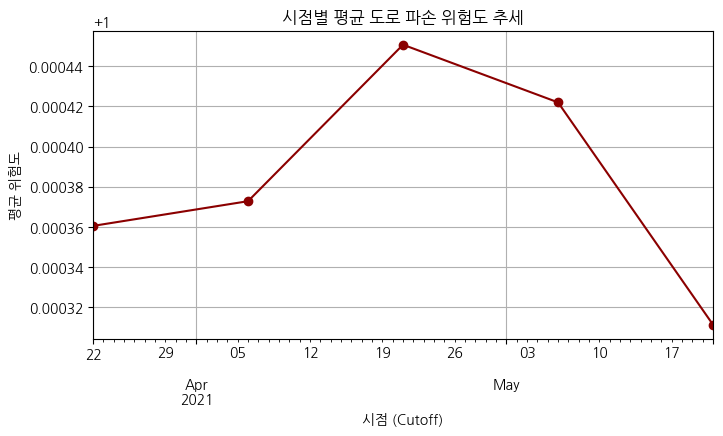

In [13]:
# ===========================================
# 5단계: 위험도 변화 분석 및 핫스팟 탐색
# ===========================================
import matplotlib.pyplot as plt

# 격자별 평균 및 표준편차 계산
trend_summary = (
    trend_df.groupby(trend_df.index)[["risk_score"]]
    .agg(["mean", "std"])
    .droplevel(0, axis=1)
    .reset_index()
)
trend_summary.rename(columns={"mean": "risk_mean", "std": "risk_std"}, inplace=True)

# 변동성 기준 상위 10개 지역
top_var = trend_summary.sort_values("risk_std", ascending=False).head(10)
print("📈 위험도 변동성이 큰 상위 10개 지역:")
print(top_var)

# 평균 위험도 기준 상위 10개 지역
top_mean = trend_summary.sort_values("risk_mean", ascending=False).head(10)
print("\n🔥 평균 위험도가 높은 상위 10개 지역:")
print(top_mean)

# ===========================================
# 시각화: 시점별 평균 위험도 추세
# ===========================================
plt.figure(figsize=(8, 4))
trend_df.groupby("cutoff")["risk_score"].mean().plot(marker="o", color="darkred")
plt.title("시점별 평균 도로 파손 위험도 추세")
plt.xlabel("시점 (Cutoff)")
plt.ylabel("평균 위험도")
plt.grid(True)
plt.show()

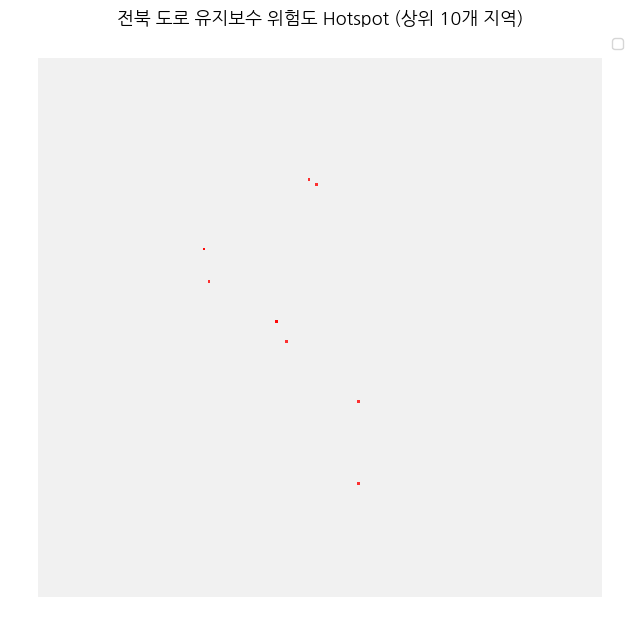

📍 상위 지역 평균 위험도 변화 요약:


,repair_cnt,compl_cnt,risk_score
cutoff,,,
2021-03-22,4.00,1.0,2.8
2021-04-06,3.00,1.0,2.2
2021-04-21,3.00,1.0,2.2
2021-05-06,4.33,1.0,3.0
2021-05-21,5.00,1.0,3.4


In [14]:
# ===========================================
# 6단계: 위험도 상위 지역 지도 표시
# ===========================================
top_hotspots = trend_df.loc[top_mean["index"]]

fig, ax = plt.subplots(figsize=(8, 8))
grid.plot(ax=ax, color="lightgray", alpha=0.3)
top_hotspots.plot(ax=ax, color="red", markersize=30, label="핫스팟", alpha=0.8)

plt.title("전북 도로 유지보수 위험도 Hotspot (상위 10개 지역)", fontsize=13)
plt.legend()
plt.axis("off")
plt.show()

# 상세 정보 출력
top_hotspots_info = (
    top_hotspots[["cutoff", "repair_cnt", "compl_cnt", "risk_score"]]
    .groupby("cutoff")
    .mean()
    .round(2)
)
print("📍 상위 지역 평균 위험도 변화 요약:")
display(top_hotspots_info)

[LightGBM] [Info] Number of positive: 73, number of negative: 170783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15
[LightGBM] [Info] Number of data points in the train set: 170856, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000427 -> initscore=-7.757690
[LightGBM] [Info] Start training from score -7.757690
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

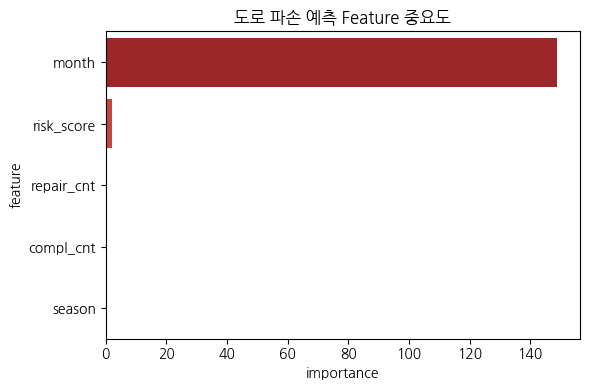

In [17]:
# ============================================================
# 전북 도로 파손 예측 프로토타입 모델 (LightGBM)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
)
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd

# ---- 1. Feature set 구성 ----
dataset = trend_df.copy()
dataset["cutoff"] = pd.to_datetime(dataset["cutoff"])
dataset["month"] = dataset["cutoff"].dt.month
dataset["season"] = dataset["month"] % 12 // 3 + 1  # 1~4 분기

# 예시: y_future (임시로 risk_score>1.5를 파손 발생으로 간주)
dataset["y_future"] = (dataset["risk_score"] > 1.5).astype(int)

features = ["repair_cnt", "compl_cnt", "risk_score", "month", "season"]
X = dataset[features]
y = dataset["y_future"]

# ---- 2. Train/Test 분할 ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ---- 3. 모델 학습 ----
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=6,
    random_state=42,
)
model.fit(X_train, y_train)

# ---- 4. 평가 ----
y_pred = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_pred)

print(f"✅ ROC-AUC: {roc_auc:.3f}")
print(f"✅ PR-AUC: {pr_auc:.3f}")
print("\n분류 리포트:\n", classification_report(y_test, (y_pred > 0.5).astype(int)))

# ---- 5. 중요 변수 시각화 ----
import matplotlib.pyplot as plt
import seaborn as sns

imp = pd.DataFrame(
    {"feature": features, "importance": model.feature_importances_}
).sort_values("importance", ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x="importance", y="feature", data=imp, palette="Reds_r")
plt.title("도로 파손 예측 Feature 중요도")
plt.tight_layout()
plt.show()